In [37]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
df = pd.read_csv('/Users/ximenamarin/Desktop/LIT/extracción de datos/Regresion_lineal/Acticidad5.1/Analisis GAC Full7agosto 2026(Leads Reales).csv', skiprows=2)

In [39]:
df.head(5)

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads,Unnamed: 12,Unnamed: 13
0,2024.0,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Febrero,543,108,33,0,1,389,1,12,3.1%,72%,NaN,NaN
2,NaN,Marzo,178,37,13,0,0,128,1,7,5.5%,72%,NaN,NaN
3,NaN,Abril,416,79,46,3,0,288,1,8,2.8%,69%,NaN,NaN
4,NaN,Mayo,422,33,100,17,0,274,5,13,4.7%,65%,NaN,NaN


In [40]:
df.columns

Index(['Año', 'Mes', 'Total', 'Ilocalizable', 'No Contesta', 'D. Incorrectos',
       'Duplicados', 'Efectivos', 'Abiertos', 'Ventas', 'Conversion ',
       'Efectividad de Leads', 'Unnamed: 12', 'Unnamed: 13'],
      dtype='str')

In [41]:
df1 = df.iloc[:29, :11]

In [42]:
df1.head(5)

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion
0,2024.0,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Febrero,543,108,33,0,1,389,1,12,3.1%
2,NaN,Marzo,178,37,13,0,0,128,1,7,5.5%
3,NaN,Abril,416,79,46,3,0,288,1,8,2.8%
4,NaN,Mayo,422,33,100,17,0,274,5,13,4.7%


In [43]:
valores_nulos=df1.isnull().sum()
valores_nulos

Año               26
Mes                0
Total              1
Ilocalizable       1
No Contesta        1
D. Incorrectos     1
Duplicados         1
Efectivos          1
Abiertos           1
Ventas             1
Conversion         1
dtype: int64

In [44]:
df1.columns

Index(['Año', 'Mes', 'Total', 'Ilocalizable', 'No Contesta', 'D. Incorrectos',
       'Duplicados', 'Efectivos', 'Abiertos', 'Ventas', 'Conversion '],
      dtype='str')

In [45]:
df1[['Año', 'Mes', 'Total', 'Ilocalizable', 'No Contesta', 'D. Incorrectos',
       'Duplicados', 'Efectivos', 'Abiertos', 'Ventas', 'Conversion ']] = df1[['Año', 'Mes', 'Total', 'Ilocalizable', 'No Contesta', 'D. Incorrectos',
       'Duplicados', 'Efectivos', 'Abiertos', 'Ventas', 'Conversion ']].fillna(0) 
df1.head(5)

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion
0,2024.0,Enero,0,0,0,0,0,0,0,0,0
1,0.0,Febrero,543,108,33,0,1,389,1,12,3.1%
2,0.0,Marzo,178,37,13,0,0,128,1,7,5.5%
3,0.0,Abril,416,79,46,3,0,288,1,8,2.8%
4,0.0,Mayo,422,33,100,17,0,274,5,13,4.7%


In [46]:
df1.dtypes

Año               float64
Mes                   str
Total              object
Ilocalizable       object
No Contesta        object
D. Incorrectos     object
Duplicados         object
Efectivos          object
Abiertos           object
Ventas             object
Conversion         object
dtype: object

In [47]:
data = df1.copy()

In [48]:
data.loc[1:12, 'Año'] = 2024

In [49]:
data.loc[12:24, 'Año'] = 2025

In [50]:
data.loc[24:, 'Año'] = 2026

In [51]:
data

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion
0,2024.0,Enero,0,0,0,0,0,0,0,0,0
1,2024.0,Febrero,543,108,33,0,1,389,1,12,3.1%
2,2024.0,Marzo,178,37,13,0,0,128,1,7,5.5%
3,2024.0,Abril,416,79,46,3,0,288,1,8,2.8%
4,2024.0,Mayo,422,33,100,17,0,274,5,13,4.7%
5,2024.0,Junio,967,140,173,31,3,620,17,6,1.0%
6,2024.0,Julio,954,112,251,12,9,570,5,21,3.7%
7,2024.0,Agosto,"1,409",504,324,17,18,546,22,17,3.1%
8,2024.0,Septiembre,"1,315",431,314,14,26,530,42,17,3.2%
9,2024.0,Octubre,"1,973",514,606,18,13,822,72,23,2.8%


In [52]:
data.dtypes

Año               float64
Mes                   str
Total              object
Ilocalizable       object
No Contesta        object
D. Incorrectos     object
Duplicados         object
Efectivos          object
Abiertos           object
Ventas             object
Conversion         object
dtype: object

In [53]:
# Convertimos a texto, eliminamos espacios y unificamos la escritura
data['Mes'] = data['Mes'].astype(str).str.strip().str.capitalize()

# Revisamos cómo quedaron
data['Mes'].unique()

<StringArray>
[     'Enero',    'Febrero',      'Marzo',      'Abril',       'Mayo',
      'Junio',      'Julio',     'Agosto', 'Septiembre',    'Octubre',
  'Noviembre',  'Diciembre']
Length: 12, dtype: str

In [54]:
meses = {
    'Enero': 1,
    'Febrero': 2,
    'Marzo': 3,
    'Abril': 4,
    'Mayo': 5,
    'Junio': 6,
    'Julio': 7,
    'Agosto': 8,
    'Septiembre': 9,
    'Octubre': 10,
    'Noviembre': 11,
    'Diciembre': 12
}

data['Mes'] = data['Mes'].map(meses)

In [55]:
data

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion
0,2024.0,1,0,0,0,0,0,0,0,0,0
1,2024.0,2,543,108,33,0,1,389,1,12,3.1%
2,2024.0,3,178,37,13,0,0,128,1,7,5.5%
3,2024.0,4,416,79,46,3,0,288,1,8,2.8%
4,2024.0,5,422,33,100,17,0,274,5,13,4.7%
5,2024.0,6,967,140,173,31,3,620,17,6,1.0%
6,2024.0,7,954,112,251,12,9,570,5,21,3.7%
7,2024.0,8,"1,409",504,324,17,18,546,22,17,3.1%
8,2024.0,9,"1,315",431,314,14,26,530,42,17,3.2%
9,2024.0,10,"1,973",514,606,18,13,822,72,23,2.8%


In [56]:
#quitamos el porcentaje para volverlo un valor numérico
data['Conversion '] = data['Conversion '].str.rstrip('%').astype(float)

In [57]:
data

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion
0,2024.0,1,0,0,0,0,0,0,0,0,NaN
1,2024.0,2,543,108,33,0,1,389,1,12,3.1
2,2024.0,3,178,37,13,0,0,128,1,7,5.5
3,2024.0,4,416,79,46,3,0,288,1,8,2.8
4,2024.0,5,422,33,100,17,0,274,5,13,4.7
5,2024.0,6,967,140,173,31,3,620,17,6,1.0
6,2024.0,7,954,112,251,12,9,570,5,21,3.7
7,2024.0,8,"1,409",504,324,17,18,546,22,17,3.1
8,2024.0,9,"1,315",431,314,14,26,530,42,17,3.2
9,2024.0,10,"1,973",514,606,18,13,822,72,23,2.8


In [58]:
#quitamos la coma en totales para volverlo un valor numérico
data['Total'] = data['Total'].str.replace(',', '').astype(float)

In [59]:
#quitamos la coma de efectivos para volverlo un valor numérico
data['Efectivos'] = data['Efectivos'].str.replace(',', '').astype(float)

In [60]:
data

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion
0,2024.0,1,NaN,0,0,0,0,NaN,0,0,NaN
1,2024.0,2,543.0,108,33,0,1,389.0,1,12,3.1
2,2024.0,3,178.0,37,13,0,0,128.0,1,7,5.5
3,2024.0,4,416.0,79,46,3,0,288.0,1,8,2.8
4,2024.0,5,422.0,33,100,17,0,274.0,5,13,4.7
5,2024.0,6,967.0,140,173,31,3,620.0,17,6,1.0
6,2024.0,7,954.0,112,251,12,9,570.0,5,21,3.7
7,2024.0,8,1409.0,504,324,17,18,546.0,22,17,3.1
8,2024.0,9,1315.0,431,314,14,26,530.0,42,17,3.2
9,2024.0,10,1973.0,514,606,18,13,822.0,72,23,2.8


In [61]:
#Pasar todas las columnas a tipo numerico
data = data.apply(pd.to_numeric, errors='coerce')

In [62]:
data.dtypes

Año               float64
Mes                 int64
Total             float64
Ilocalizable        int64
No Contesta         int64
D. Incorrectos      int64
Duplicados          int64
Efectivos         float64
Abiertos            int64
Ventas              int64
Conversion        float64
dtype: object

In [63]:
#volemos a 0 los NA
data = data.fillna(0)

In [64]:
data

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion
0,2024.0,1,0.0,0,0,0,0,0.0,0,0,0.0
1,2024.0,2,543.0,108,33,0,1,389.0,1,12,3.1
2,2024.0,3,178.0,37,13,0,0,128.0,1,7,5.5
3,2024.0,4,416.0,79,46,3,0,288.0,1,8,2.8
4,2024.0,5,422.0,33,100,17,0,274.0,5,13,4.7
5,2024.0,6,967.0,140,173,31,3,620.0,17,6,1.0
6,2024.0,7,954.0,112,251,12,9,570.0,5,21,3.7
7,2024.0,8,1409.0,504,324,17,18,546.0,22,17,3.1
8,2024.0,9,1315.0,431,314,14,26,530.0,42,17,3.2
9,2024.0,10,1973.0,514,606,18,13,822.0,72,23,2.8


In [65]:
data.columns

Index(['Año', 'Mes', 'Total', 'Ilocalizable', 'No Contesta', 'D. Incorrectos',
       'Duplicados', 'Efectivos', 'Abiertos', 'Ventas', 'Conversion '],
      dtype='str')

In [30]:
# Seleccionamos únicamente las variables de la regresión

variables_regresion = data[['Año', 'Mes', 'Total','No Contesta','Efectivos','Abiertos']]

<Axes: xlabel='Efectivos', ylabel='Total'>

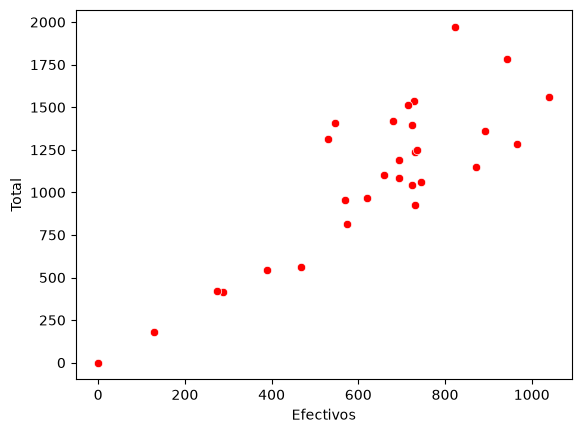

In [66]:
from turtle import color
sns.scatterplot(x='Efectivos', y='Total', color="red", data=variables_regresion)

In [67]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= data[['Efectivos']]
Var_Dep= data['Total']

In [68]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [69]:
#Se define model como la función de regresión lineal
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [70]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.64]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Efectivos']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,39.85
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [71]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Efectivos'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([1.63840224]),
 'rank_': np.int64(1),
 'singular_': array([1278.02849248]),
 'intercept_': np.float64(39.85424212476482)}

In [72]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.7278141398316158

In [74]:
y_pred= model.predict(X=variables_regresion[['Efectivos']])
y_pred

array([  39.85424212,  677.19271294,  249.56972867,  511.71408684,
        488.7764555 , 1055.66363006,  973.74351813,  934.4218644 ,
        908.20742859, 1386.62088226, 1743.79257027, 1620.91240238,
       1224.41906064,  806.62648979, 1237.52627855, 1468.54099419,
        980.29712708, 1176.90539572, 1502.9474412 , 1155.60616662,
       1121.1997196 , 1178.54379796, 1258.82550765, 1234.24947407,
       1209.67344049, 1235.88787631, 1586.50595537, 1226.05746288,
       1245.71828974])

In [75]:
#Insertamos la columna de predicciones en el DataFrame
variables_regresion.insert(0, 'Predicciones', y_pred)
variables_regresion

,Predicciones,Año,Mes,Total,No Contesta,Efectivos,Abiertos
0,39.854242,2024.0,1,0.0,0,0.0,0
1,677.192713,2024.0,2,543.0,33,389.0,1
2,249.569729,2024.0,3,178.0,13,128.0,1
3,511.714087,2024.0,4,416.0,46,288.0,1
4,488.776456,2024.0,5,422.0,100,274.0,5
5,1055.663630,2024.0,6,967.0,173,620.0,17
6,973.743518,2024.0,7,954.0,251,570.0,5
7,934.421864,2024.0,8,1409.0,324,546.0,22
8,908.207429,2024.0,9,1315.0,314,530.0,42
9,1386.620882,2024.0,10,1973.0,606,822.0,72


<Axes: xlabel='Efectivos', ylabel='Total'>

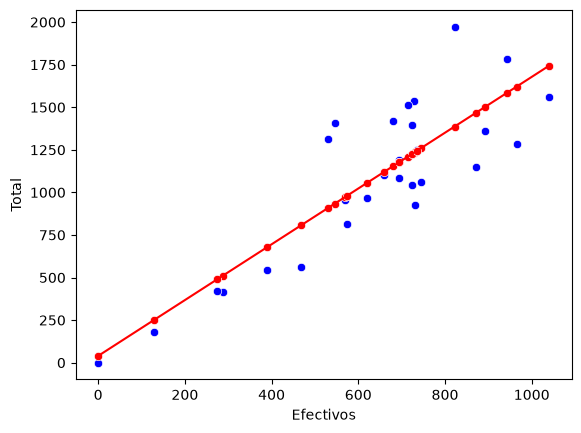

In [76]:
sns.scatterplot(x='Efectivos', y='Total', color="blue", data=variables_regresion)
sns.scatterplot(x='Efectivos', y='Predicciones', color="red", data=variables_regresion)
sns.lineplot(x='Efectivos', y='Predicciones', color="red", data=variables_regresion)

In [77]:
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
coef_Deter

0.7278141398316158

In [78]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
coef_Correl

np.float64(0.8531202376169585)

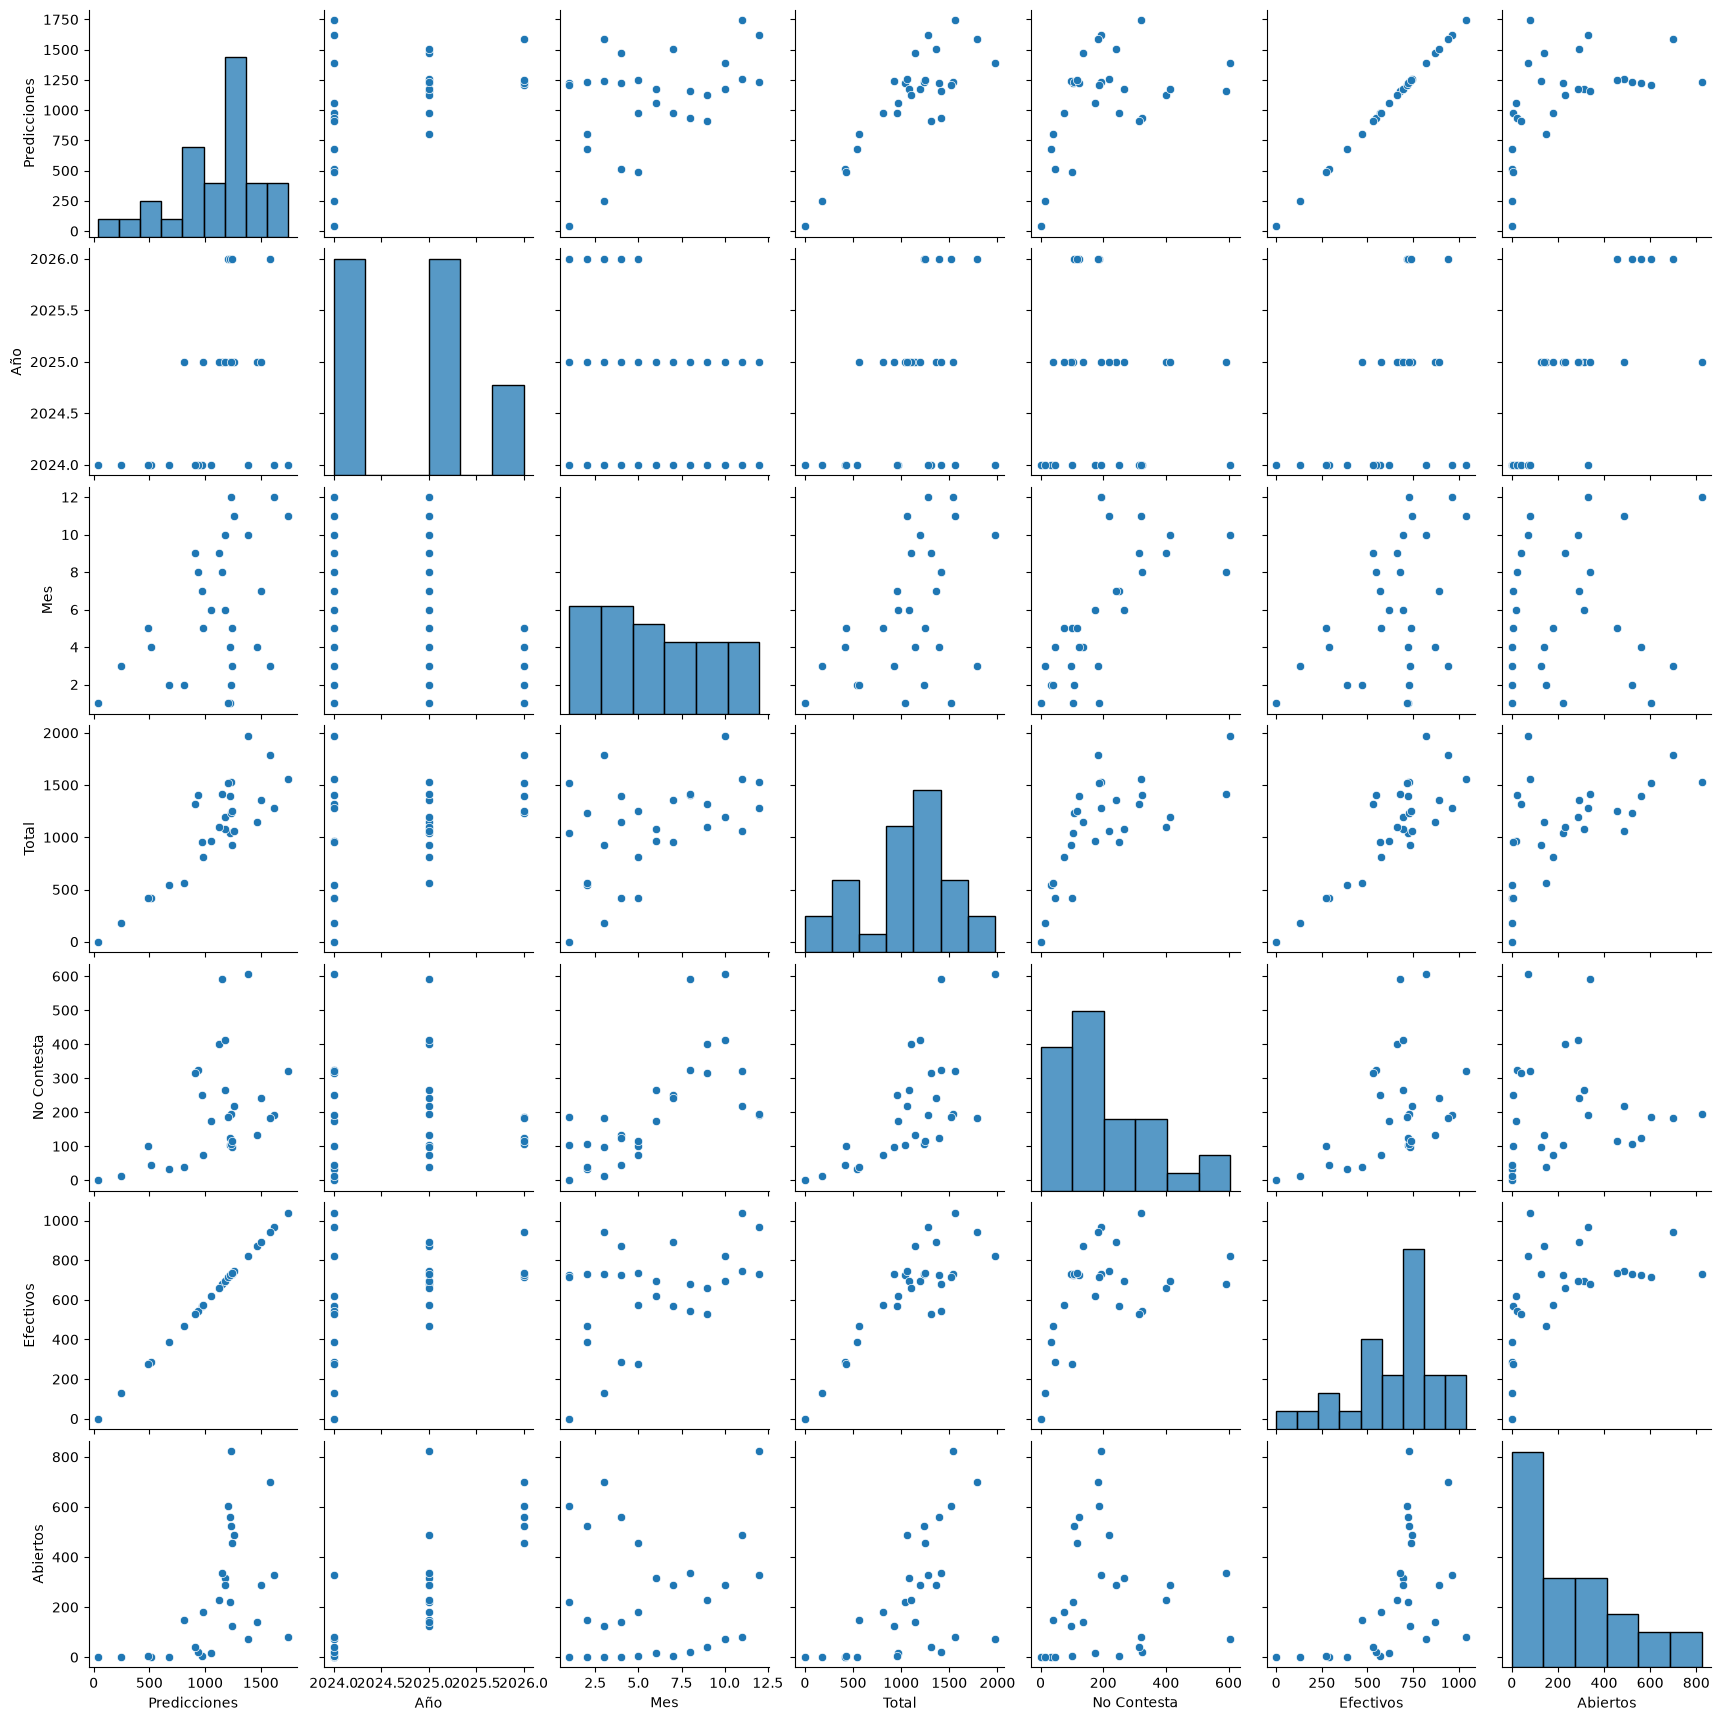

In [79]:
#Graficamos todas las dispersiones entre todas las variables
sns.pairplot(variables_regresion)

In [80]:
#Encontramos todas las correlaciones entre las variables 
Corr_Factors=variables_regresion.corr()
Corr_Factors

,Predicciones,Año,Mes,Total,No Contesta,Efectivos,Abiertos
Predicciones,1.000000,0.427469,0.431038,0.853120,0.446789,1.000000,0.518063
Año,0.427469,1.000000,-0.298181,0.390258,-0.075146,0.427469,0.808063
Mes,0.431038,-0.298181,1.000000,0.479697,0.665231,0.431038,0.103614
Total,0.853120,0.390258,0.479697,1.000000,0.669922,0.853120,0.551099
No Contesta,0.446789,-0.075146,0.665231,0.669922,1.000000,0.446789,0.061847
Efectivos,1.000000,0.427469,0.431038,0.853120,0.446789,1.000000,0.518063
Abiertos,0.518063,0.808063,0.103614,0.551099,0.061847,0.518063,1.000000


In [81]:
#Encontramos el valor absoluto de todas las correlaciones entre las variables 
Corr_Factors1= abs(Corr_Factors)
Corr_Factors1

,Predicciones,Año,Mes,Total,No Contesta,Efectivos,Abiertos
Predicciones,1.000000,0.427469,0.431038,0.853120,0.446789,1.000000,0.518063
Año,0.427469,1.000000,0.298181,0.390258,0.075146,0.427469,0.808063
Mes,0.431038,0.298181,1.000000,0.479697,0.665231,0.431038,0.103614
Total,0.853120,0.390258,0.479697,1.000000,0.669922,0.853120,0.551099
No Contesta,0.446789,0.075146,0.665231,0.669922,1.000000,0.446789,0.061847
Efectivos,1.000000,0.427469,0.431038,0.853120,0.446789,1.000000,0.518063
Abiertos,0.518063,0.808063,0.103614,0.551099,0.061847,0.518063,1.000000


<Axes: >

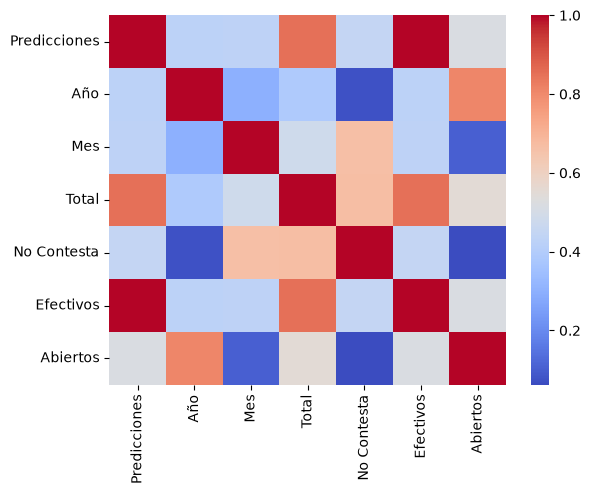

In [82]:
 #Graficamos el mapa de calor de los coeficientes de correlación 
Heat_Map= sns.heatmap(Corr_Factors1, cmap = 'coolwarm')  
Heat_Map

<Axes: >

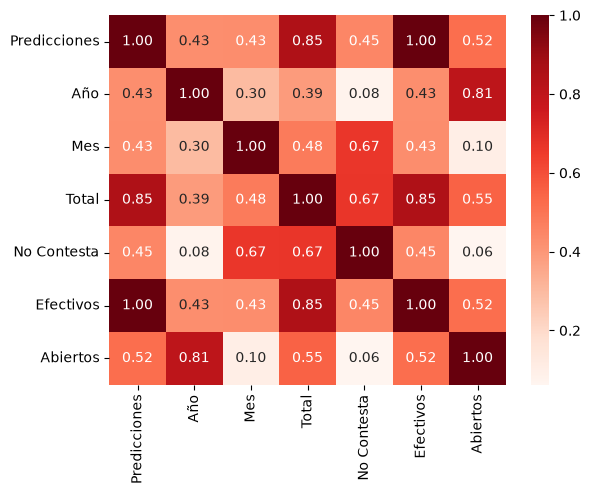

In [83]:
#Ajustamos el mapa de calor de los coeficientes de correlación 
Heat_Map= sns.heatmap(Corr_Factors1, cmap = 'Reds', annot=True, fmt=".2f")  
Heat_Map